# Visualization & Longitudinal Analysis Uisng NLCD and xxx

About NLCD



### NLCD Class Code
https://www.mrlc.gov/data/legends/national-land-cover-database-class-legend-and-description

| Class Code | Class Name                   |
| ---------- | ---------------------------- |
| 11         | Open Water                   |
| 12         | Perennial Ice/Snow           |
| 21         | Developed, Open Space        |
| 22         | Developed, Low Intensity     |
| 23         | Developed, Medium Intensity  |
| 24         | Developed, High Intensity    |
| 31         | Barren Land (Rock/Sand/Clay) |
| 41         | Deciduous Forest             |
| 42         | Evergreen Forest             |
| 43         | Mixed Forest                 |
| 52         | Shrub/Scrub                  |
| 71         | Grassland/Herbaceous         |
| 81         | Pasture/Hay                  |
| 82         | Cultivated Crops             |
| 90         | Woody Wetlands               |
| 95         | Emergent Herbaceous Wetlands |


In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import ee
print(ee.__version__)
ee.Authenticate()  # Regular auth — follow the link and paste the token
ee.Initialize(project='utility-realm-255220')

1.7.22


In [3]:
import geemap
geemap.ee_initialize()

In [4]:
# Load 2021 NLCD ImageCollection
nlcd_ic = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD")

# Get distinct years by inspecting the 'system:index' property
def extract_year(image):
    return ee.Feature(None, {'year': ee.String(image.get('system:index')).slice(0, 4)})

years = nlcd_ic.map(extract_year).aggregate_array('year').distinct().sort()
print('Available NLCD years:', years.getInfo())


Available NLCD years: ['2021']


In [5]:
# Load the 2019 release NLCD ImageCollection
nlcd_ic = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")

# Get distinct years by inspecting the 'system:index' property
def extract_year(image):
    return ee.Feature(None, {'year': ee.String(image.get('system:index')).slice(0, 4)})

years = nlcd_ic.map(extract_year).aggregate_array('year').distinct().sort()
print('Available NLCD years:', years.getInfo())

Available NLCD years: ['2001', '2004', '2006', '2008', '2011', '2013', '2016', '2019']


Use USGS/NLCD_RELEASES/2019_REL/NLCD for 2001–2019

Use USGS/NLCD_RELEASES/2021_REL/NLCD for 2021

## Visualizing Land Cover Change

In [ ]:
# Define bounding box coordinates
bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)

# Create a geemap interactive map
Map = geemap.Map(center=[33.105, -96.669], zoom=13)

# Add the bounding box as a red outline
Map.addLayer(bbox, {'color': 'red'}, 'Bounding Box')

# Display the map
Map

Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

In [ ]:


# Define your area of interest (Allen, TX bounding box)
bbox = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])

# List of NLCD years to visualize
nlcd_years = [2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019, 2021]

# NLCD class values and custom color palette
nlcd_classes = [11, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95]
nlcd_palette = [
    '466b9f',  # Open Water
    'dec5c5',  # Developed, Open Space
    'd99282',  # Developed, Low Intensity
    'eb0000',  # Developed, Medium Intensity
    '8000ff',  # Developed, High Intensity (purple for clarity)
    'b3ac9f',  # Barren Land
    '68ab5f',  # Deciduous Forest
    '1c5f2c',  # Evergreen Forest
    'b5c58f',  # Mixed Forest
    'af963c',  # Shrub/Scrub
    'cdc9c9',  # Grassland/Herbaceous
    'fb9f3a',  # Pasture/Hay
    'dcd939',  # Cultivated Crops
    'ab6c28',  # Woody Wetlands
    'b8d9eb'   # Emergent Herbaceous Wetlands
]

# Create map
Map = geemap.Map(center=[33.105, -96.669], zoom=13)

# Loop through each year and add remapped NLCD layer
for year in nlcd_years:
    if year == 2021:
        nlcd_img = ee.Image(f'USGS/NLCD_RELEASES/2021_REL/NLCD/{year}').select('landcover')
    else:
        nlcd_img = ee.Image(f'USGS/NLCD_RELEASES/2019_REL/NLCD/{year}').select('landcover')

    # Remap NLCD class values to sequential indices for palette matching
    remapped = nlcd_img.remap(nlcd_classes, list(range(len(nlcd_classes))))

    # Add layer to map
    Map.addLayer(remapped.clip(bbox), {
        'min': 0,
        'max': len(nlcd_palette) - 1,
        'palette': nlcd_palette
    }, f'NLCD {year}')

# Legend entries (color and label)
legend_dict = {
    'Open Water': '466b9f',
    'Developed, Open Space': 'dec5c5',
    'Developed, Low Intensity': 'd99282',
    'Developed, Medium Intensity': 'eb0000',
    'Developed, High Intensity': '8000ff',
    'Barren Land': 'b3ac9f',
    'Deciduous Forest': '68ab5f',
    'Evergreen Forest': '1c5f2c',
    'Mixed Forest': 'b5c58f',
    'Shrub/Scrub': 'af963c',
    'Grassland/Herbaceous': 'cdc9c9',
    'Pasture/Hay': 'fb9f3a',
    'Cultivated Crops': 'dcd939',
    'Woody Wetlands': 'ab6c28',
    'Emergent Herbaceous Wetlands': 'b8d9eb'
}

# Add legend to the map on the left
Map.add_legend(
    title='NLCD Land Cover Classes',
    legend_dict=legend_dict,
    position='bottomleft'
)

# Display the map
Map


Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

## Visualizing Nightime Light Radiance: Urban Expansion with Light Pollution

🔗 **VIIRS Stray Light Corrected Nighttime Day/Night Band Composites Version 1**

* **Data ID**: `NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG`
* **Coverage**: **April 2014 – March 2025**
* **Bands**:

  * `avg_rad`: average radiance (nanowatts/cm²/sr)
  * `cf_cvg`: cloud-free coverage count (to assess data quality) ([developers.google.com][2])
* **Provided by**: Earth Observation Group, Payne Institute (Colorado School of Mines) ([developers.google.com][2])
* **Description**:

  * Monthly average radiance composite images using nighttime data from the Visible Infrared Imaging Radiometer Suite (VIIRS) Day/Night Band (DNB).
  * Stray-light corrections applied, but can still include ephemeral lights (fires, boats, auroras) ([developers.google.com][2])

---



**Dataset Catalog**:
https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMSLCFG

---


In [ ]:
import datetime

# Define the ImageCollection
collection = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')

# Get list of available timestamps and convert to readable months
def get_dates(ic):
    timestamps = ic.aggregate_array('system:time_start').getInfo()
    months = sorted(set(datetime.datetime.utcfromtimestamp(ts / 1000).strftime('%Y-%m') for ts in timestamps))
    return months

# Print available months
available_months = get_dates(collection)
for month in available_months:
    print(month)


2014-01
2014-02
2014-03
2014-04
2014-05
2014-06
2014-07
2014-08
2014-09
2014-10
2014-11
2014-12
2015-01
2015-02
2015-03
2015-04
2015-05
2015-06
2015-07
2015-08
2015-09
2015-10
2015-11
2015-12
2016-01
2016-02
2016-03
2016-04
2016-05
2016-06
2016-07
2016-08
2016-09
2016-10
2016-11
2016-12
2017-01
2017-02
2017-03
2017-04
2017-05
2017-06
2017-07
2017-08
2017-09
2017-10
2017-11
2017-12
2018-01
2018-02
2018-03
2018-04
2018-05
2018-06
2018-07
2018-08
2018-09
2018-10
2018-11
2018-12
2019-01
2019-02
2019-03
2019-04
2019-05
2019-06
2019-07
2019-08
2019-09
2019-10
2019-11
2019-12
2020-01
2020-02
2020-03
2020-04
2020-05
2020-06
2020-07
2020-08
2020-09
2020-10
2020-11
2020-12
2021-01
2021-02
2021-03
2021-04
2021-05
2021-06
2021-07
2021-08
2021-09
2021-10
2021-11
2021-12
2022-01
2022-02
2022-03
2022-04
2022-05
2022-06
2022-07
2022-08
2022-09
2022-10
2022-11
2022-12
2023-01
2023-02
2023-03
2023-04
2023-05
2023-06
2023-07
2023-08
2023-09
2023-10
2023-11
2023-12
2024-01
2024-02
2024-03
2024-04
2024-05


In [ ]:
# Check if any images are available for November 2024
ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG') \
  .filterDate('2024-11-01', '2024-11-30') \
  .size() \
  .getInfo()


0

The brightest nighttime radiance areas are concentrated along Highway 75 and 121.

This aligns with my urbanization map, where high-intensity development is also clustered along Highway 75.

The comparison between 2014 and 2025 shows a clear increase in nighttime brightness, which correlates with increased urban development.

In [ ]:
# import geemap
# import ee

# # Initialize Earth Engine
# ee.Initialize()

# # Define the bounding box for Allen, TX
# bbox = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])

# Define the time range (e.g., Jan 2021)
night_img = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG') \
    .filterDate('2025-03-01', '2025-03-30') \
    .select('avg_rad') \
    .median() \
    .clip(bbox)

# Visualization parameters
vis_params = {
    'min': 0,
    'max': 60,
    'palette': ['000000', '0c0c3f', '1c3c74', '3f5ba9', '8fa2dd', 'ffffff']
}

# Create map and add layer
Map = geemap.Map(center=[33.105, -96.669], zoom=13)
Map.addLayer(night_img, vis_params, 'Nighttime Light March 2025')
Map.addLayer(bbox, {'color': 'red'}, 'Bounding Box')

# Define a simple legend for brightness levels
legend_dict = {
    'Very Low': '000000',
    'Low': '0c0c3f',
    'Moderate': '1c3c74',
    'High': '3f5ba9',
    'Very High': '8fa2dd',
    'Max': 'ffffff'
}

# Add the legend to the map
Map.add_legend(
    title='Nighttime Radiance (nW/cm²/sr)',
    legend_dict=legend_dict,
    position='bottomleft'
)

# Map.add_text(
#     text='Allen, TX - Nighttime Radiance (Mar 2025)',
#     position='topright',
#     font_size=20,
#     font_color='black',
#     font_family='Arial',
#     bold=True
# )

Map



Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

In [ ]:
bbox = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])
# Define the earliest available time range (April 2012)
night_img = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG') \
    .filterDate('2014-01-01', '2014-01-31') \
    .select('avg_rad') \
    .median() \
    .clip(bbox)

# Visualization parameters
vis_params = {
    'min': 0,
    'max': 60,
    'palette': ['000000', '0c0c3f', '1c3c74', '3f5ba9', '8fa2dd', 'ffffff']
}

# Create map and add layer
Map = geemap.Map(center=[33.105, -96.669], zoom=13)
Map.addLayer(night_img, vis_params, 'Nighttime Light Apr 2012')
Map.addLayer(bbox, {'color': 'red'}, 'Bounding Box')

# Define a simple legend for brightness levels
legend_dict = {
    'Very Low': '000000',
    'Low': '0c0c3f',
    'Moderate': '1c3c74',
    'High': '3f5ba9',
    'Very High': '8fa2dd',
    'Max': 'ffffff'
}

# Add the legend to the map
Map.add_legend(
    title='Nighttime Radiance (nW/cm²/sr)',
    legend_dict=legend_dict,
    position='bottomleft'
)

Map


Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=night_img,
    description='Nightlight_2021_01_Allen',
    folder='EarthEngineExports',   # change to your Drive folder name
    fileNamePrefix='nightlight_allen_2021_01',
    region=bbox,
    scale=30,  # VIIRS native resolution ~450m, but EE supports scaling; adjust if needed
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()

In [ ]:

# Get nighttime lights for Jan 2021
night_img = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG') \
    .filterDate('2021-01-01', '2021-01-31') \
    .select('avg_rad') \
    .median() \
    .clip(bbox)

# Visualization parameters
vis_params = {
    'min': 0,
    'max': 60,
    'palette': ['000000', '0c0c3f', '1c3c74', '3f5ba9', '8fa2dd', 'ffffff']
}

# Create the map
Map = geemap.Map(center=[33.105, -96.669], zoom=13)
Map.addLayer(night_img, vis_params, 'Nighttime Light Jan 2021')

# Custom legend dictionary with brightness levels
legend_dict = {
    'Very Low': '000000',
    'Low': '0c0c3f',
    'Moderate': '1c3c74',
    'High': '3f5ba9',
    'Very High': '8fa2dd',
    'Max': 'ffffff'
}

# Add the legend near the top center (simulated by choosing 'topright' or 'topleft' with CSS margin)
Map.add_legend(
    title='Nighttime Radiance (nW/cm²/sr)',
    legend_dict=legend_dict,
    position='topleft'  # 'topright' places it away from Earth Engine panel
)

Map


Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

Open Earth Engine Task Manager https://code.earthengine.google.com/tasks


In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 75.7 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


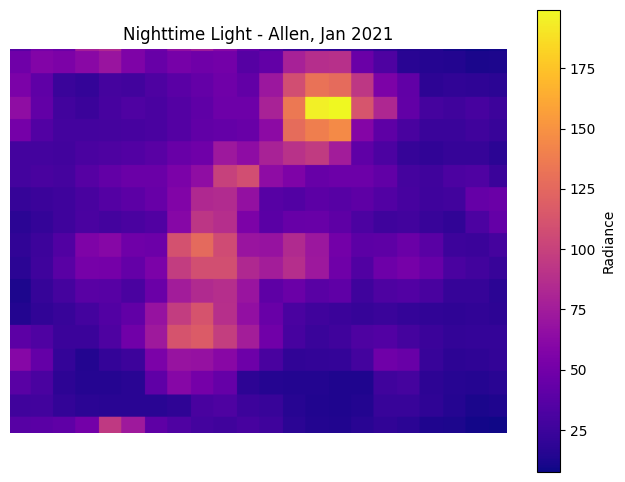

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import rasterio
import matplotlib.pyplot as plt

# Update the path to match your file name
file_path = '/content/drive/My Drive/EarthEngineExports/nightlight_allen_2021_01.tif'

with rasterio.open(file_path) as src:
    img = src.read(1)
    plt.figure(figsize=(8, 6))
    plt.imshow(img, cmap='plasma')
    plt.colorbar(label='Radiance')
    plt.title('Nighttime Light - Allen, Jan 2021')
    plt.axis('off')
    plt.show()


In [ ]:
# Map.to_image(filename='nightlight_allen_2021.png')

## Visualize Light Radiance using Sentinel-2
https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED

In [ ]:
import folium
from datetime import date

In [ ]:
# Allen, TX bounding box
allen_roi = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])

# Filter Sentinel-2 Surface Reflectance (harmonized)
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(allen_roi) \
    .filterDate('2023-06-01', '2023-06-30') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))

# Composite by median to reduce cloud effect
s2_median = s2.median().clip(allen_roi)


In [ ]:
# Visualization parameters for true-color RGB
vis_params = {
    'bands': ['B4', 'B3', 'B2'],  # RGB
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Create folium map centered on Allen, TX
map_center = [33.105, -96.669]
m = folium.Map(location=map_center, zoom_start=13)

# Add Sentinel-2 imagery to the map
map_id_dict = ee.Image(s2_median).getMapId(vis_params)
folium.TileLayer(
    tiles=map_id_dict['tile_fetcher'].url_format,
    attr='Map Data © Google Earth Engine',
    name='Sentinel-2 True Color',
    overlay=True,
    control=True
).add_to(m)

# Add layer control and display map
folium.LayerControl().add_to(m)
m


In [ ]:
# Load VIIRS nighttime radiance (monthly average)
viirs = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG') \
    .filterBounds(allen_roi) \
    .filterDate('2023-06-01', '2023-06-30')

viirs_img = viirs.mean().clip(allen_roi)

viirs_vis = {
    'bands': ['avg_rad'],
    'min': 0,
    'max': 40,
    'palette': ['000000', 'ffff00', 'ff0000', 'ffffff']
}

# Add VIIRS to map
map_id_viirs = ee.Image(viirs_img).getMapId(viirs_vis)
folium.TileLayer(
    tiles=map_id_viirs['tile_fetcher'].url_format,
    attr='NOAA VIIRS via Google Earth Engine',
    name='VIIRS Nighttime Radiance',
    overlay=True,
    control=True
).add_to(m)

m


In [ ]:
# No base tiles
m = folium.Map(location=map_center, zoom_start=13, tiles=None)

# Add false-color Sentinel-2
map_id_dict = ee.Image(s2_median).getMapId(vis_params)
folium.TileLayer(
    tiles=map_id_dict['tile_fetcher'].url_format,
    attr='Sentinel-2 False Color',
    name='Sentinel-2 Vegetation',
    overlay=True,
    control=True
).add_to(m)

folium.LayerControl().add_to(m)
m


## Calculate Urbanization Land Cover YOY Change

In [ ]:
# Define NLCD land cover classes (simplified)
nlcd_classes = {
    11: 'Open Water',
    21: 'Developed, Open Space',
    22: 'Developed, Low Intensity',
    23: 'Developed, Medium Intensity',
    24: 'Developed, High Intensity',
    31: 'Barren Land',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    51: 'Dwarf Scrub',
    52: 'Shrub/Scrub',
    71: 'Grassland/Herbaceous',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Emergent Herbaceous Wetlands'
}

# Available NLCD years in GEE
nlcd_years = [2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019]

# Main analysis function
def analyze_nlcd_trends(roi):
    results = []

    for year in nlcd_years:
        image = ee.Image(f'USGS/NLCD_RELEASES/2019_REL/NLCD/{year}').select('landcover').clip(roi)
        stats = image.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            geometry=roi,
            scale=30,
            maxPixels=1e9
        )
        freq_dict = stats.get('landcover').getInfo()
        total = sum(freq_dict.values())
        for class_id, label in nlcd_classes.items():
            count = freq_dict.get(str(class_id), 0)
            percent = round(100 * count / total, 2)
            results.append({
                'Year': year,
                'Land Cover': label,
                'Percent': percent
            })

    df = pd.DataFrame(results)
    df_pivot = df.pivot(index='Land Cover', columns='Year', values='Percent').fillna(0)
    df_pivot['Change (2019 - 2001)'] = df_pivot[2019] - df_pivot[2001]
    return df_pivot.sort_index()

In [ ]:
allen_roi = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])  # Approximate bounding box for Allen
allen_boundingbox_stats_2001_2019 = analyze_nlcd_trends(allen_roi)
display(allen_boundingbox_stats_2001_2019)

Year,2001,2004,2006,2008,2011,2013,2016,2019,Change (2019 - 2001)
Land Cover,,,,,,,,,
Barren Land,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.01
Cultivated Crops,10.16,10.28,9.43,7.06,6.56,6.53,5.23,4.47,-5.69
Deciduous Forest,5.66,5.28,4.93,4.65,4.45,4.31,4.14,3.95,-1.71
"Developed, High Intensity",8.32,9.05,9.89,11.50,12.38,12.64,13.65,14.95,6.63
"Developed, Low Intensity",14.24,14.66,14.70,16.15,16.07,16.19,16.57,16.52,2.28
"Developed, Medium Intensity",33.61,35.33,37.70,41.17,42.77,44.06,45.75,47.26,13.65
"Developed, Open Space",7.87,7.94,8.03,8.39,8.61,8.30,8.20,7.76,-0.11
Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Emergent Herbaceous Wetlands,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02


In [ ]:
allen_boundingbox_stats_2001_2019.reset_index(inplace=True)

In [ ]:
allen_boundingbox_stats_2001_2019.columns

Index([          'Land Cover',                   2001,                   2004,
                         2006,                   2008,                   2011,
                         2013,                   2016,                   2019,
       'Change (2019 - 2001)'],
      dtype='object', name='Year')

In [ ]:
# Function to analyze only NLCD 2021
def analyze_nlcd_2021(roi):
    year = 2021
    image = ee.Image(f'USGS/NLCD_RELEASES/2021_REL/NLCD/{year}').select('landcover').clip(roi)
    stats = image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=roi,
        scale=30,
        maxPixels=1e9
    )
    freq_dict = stats.get('landcover').getInfo()
    total = sum(freq_dict.values())

    results = []
    for class_id, label in nlcd_classes.items():
        count = freq_dict.get(str(class_id), 0)
        percent = round(100 * count / total, 2)
        results.append({
            'Land Cover': label,
            '2021': percent
        })

    df = pd.DataFrame(results)
    return df.sort_values(by='2021', ascending=False).reset_index(drop=True)

In [ ]:
allen_roi = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])  # Approximate bounding box for Allen
allen_boundingbox_stats_2021 = analyze_nlcd_2021(allen_roi)
display(allen_boundingbox_stats_2021)

,Land Cover,2021
0,"Developed, Medium Intensity",48.13
1,"Developed, Low Intensity",16.79
2,"Developed, High Intensity",15.27
3,"Developed, Open Space",7.62
4,Deciduous Forest,3.89
5,Grassland/Herbaceous,3.55
6,Cultivated Crops,3.30
7,Pasture/Hay,1.01
8,Barren Land,0.14
9,Open Water,0.11


In [ ]:
allen_boundingbox_stats_2021.columns

Index(['Land Cover', '2021'], dtype='object')

In [ ]:
allen_boundingbox_stats_2001_2021 = pd.merge(allen_boundingbox_stats_2001_2019.drop(['Change (2019 - 2001)'], axis=1), allen_boundingbox_stats_2021, on='Land Cover', how='outer')

In [ ]:
allen_boundingbox_stats_2001_2021

,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021
0,Barren Land,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.14
1,Cultivated Crops,10.16,10.28,9.43,7.06,6.56,6.53,5.23,4.47,3.30
2,Deciduous Forest,5.66,5.28,4.93,4.65,4.45,4.31,4.14,3.95,3.89
3,"Developed, High Intensity",8.32,9.05,9.89,11.50,12.38,12.64,13.65,14.95,15.27
4,"Developed, Low Intensity",14.24,14.66,14.70,16.15,16.07,16.19,16.57,16.52,16.79
5,"Developed, Medium Intensity",33.61,35.33,37.70,41.17,42.77,44.06,45.75,47.26,48.13
6,"Developed, Open Space",7.87,7.94,8.03,8.39,8.61,8.30,8.20,7.76,7.62
7,Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,Emergent Herbaceous Wetlands,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02
9,Evergreen Forest,0.14,0.10,0.09,0.09,0.09,0.09,0.09,0.07,0.07


In [ ]:
df_nlcd=allen_boundingbox_stats_2001_2021.copy()

# Define NLCD category mapping
nlcd_groups = {
    'Open Water': 'Water',
    'Developed, Open Space': 'Developed',
    'Developed, Low Intensity': 'Developed',
    'Developed, Medium Intensity': 'Developed',
    'Developed, High Intensity': 'Developed',
    'Barren Land': 'Barren',
    'Deciduous Forest': 'Forest',
    'Evergreen Forest': 'Forest',
    'Mixed Forest': 'Forest',
    'Dwarf Scrub': 'Shrubland',
    'Shrub/Scrub': 'Shrubland',
    'Grassland/Herbaceous': 'Grassland',
    'Pasture/Hay': 'Agriculture',
    'Cultivated Crops': 'Agriculture',
    'Woody Wetlands': 'Wetlands',
    'Emergent Herbaceous Wetlands': 'Wetlands'
}

# Add a new column for the group
df_nlcd['NLCD Group'] = df_nlcd['Land Cover'].map(nlcd_groups)

# Define custom sort order
group_order = [
    'Water', 'Developed', 'Forest', 'Shrubland',
    'Grassland', 'Agriculture', 'Wetlands', 'Barren'
]

# Sort the DataFrame by group and then by land cover label
df_sorted = df_nlcd.copy()
df_sorted['Group Order'] = df_sorted['NLCD Group'].map(lambda x: group_order.index(x))
df_sorted = df_sorted.sort_values(by=['Group Order', 'Land Cover']).drop(columns='Group Order')

# Optional: move 'NLCD Group' column next to 'Land Cover'
cols = ['NLCD Group', 'Land Cover'] + [col for col in df_sorted.columns if col not in ['NLCD Group', 'Land Cover']]
df_sorted = df_sorted[cols]

# Display the sorted table
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_sorted


,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021
12,Water,Open Water,0.12,0.10,0.11,0.15,0.12,0.12,0.13,0.11,0.11
3,Developed,"Developed, High Intensity",8.32,9.05,9.89,11.50,12.38,12.64,13.65,14.95,15.27
4,Developed,"Developed, Low Intensity",14.24,14.66,14.70,16.15,16.07,16.19,16.57,16.52,16.79
5,Developed,"Developed, Medium Intensity",33.61,35.33,37.70,41.17,42.77,44.06,45.75,47.26,48.13
6,Developed,"Developed, Open Space",7.87,7.94,8.03,8.39,8.61,8.30,8.20,7.76,7.62
2,Forest,Deciduous Forest,5.66,5.28,4.93,4.65,4.45,4.31,4.14,3.95,3.89
9,Forest,Evergreen Forest,0.14,0.10,0.09,0.09,0.09,0.09,0.09,0.07,0.07
11,Forest,Mixed Forest,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02
7,Shrubland,Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
14,Shrubland,Shrub/Scrub,0.15,0.11,0.13,0.16,0.11,0.14,0.14,0.10,0.10


In [ ]:
# Define the desired NLCD label order based on MRLC category legend
nlcd_label_order = [
    'Open Water',
    'Developed, Open Space',
    'Developed, Low Intensity',
    'Developed, Medium Intensity',
    'Developed, High Intensity',
    'Barren Land',
    'Deciduous Forest',
    'Evergreen Forest',
    'Mixed Forest',
    'Shrub/Scrub',
    'Grassland/Herbaceous',
    'Pasture/Hay',
    'Cultivated Crops',
    'Woody Wetlands',
    'Emergent Herbaceous Wetlands',
    'Dwarf Scrub'  # this may appear in western states; include it last or as needed
]

# Convert 'Land Cover' column to categorical using the defined order
df_sorted['Land Cover'] = pd.Categorical(df_sorted['Land Cover'], categories=nlcd_label_order, ordered=True)

# Sort the DataFrame accordingly
df_ordered = df_sorted.sort_values('Land Cover').reset_index(drop=True)

In [ ]:
df_ordered

,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021
0,Water,Open Water,0.12,0.10,0.11,0.15,0.12,0.12,0.13,0.11,0.11
1,Developed,"Developed, Open Space",7.87,7.94,8.03,8.39,8.61,8.30,8.20,7.76,7.62
2,Developed,"Developed, Low Intensity",14.24,14.66,14.70,16.15,16.07,16.19,16.57,16.52,16.79
3,Developed,"Developed, Medium Intensity",33.61,35.33,37.70,41.17,42.77,44.06,45.75,47.26,48.13
4,Developed,"Developed, High Intensity",8.32,9.05,9.89,11.50,12.38,12.64,13.65,14.95,15.27
5,Barren,Barren Land,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.14
6,Forest,Deciduous Forest,5.66,5.28,4.93,4.65,4.45,4.31,4.14,3.95,3.89
7,Forest,Evergreen Forest,0.14,0.10,0.09,0.09,0.09,0.09,0.09,0.07,0.07
8,Forest,Mixed Forest,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02
9,Shrubland,Shrub/Scrub,0.15,0.11,0.13,0.16,0.11,0.14,0.14,0.10,0.10


In [ ]:
df_ordered.columns=['NLCD Group', 'Land Cover',  '2001', '2004', '2006','2008','2011','2013','2016','2019','2021']
print(df_ordered.columns)

In [ ]:
df_ordered['2021 - 2001 Change'] = df_ordered['2021'] - df_ordered['2001']

We observed a significant gap between the percentage of grassland between NLCD and RSA.

NLCD 71 Grassland/Herbaceous- areas dominated by gramanoid or herbaceous vegetation, generally greater than 80% of total vegetation. These areas are not subject to intensive management such as tilling, but can be utilized for grazing. Excludes area used for hay/pasture.

RSA

In [ ]:
df_ordered

,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021,2021 - 2001 Change
0,Water,Open Water,0.12,0.10,0.11,0.15,0.12,0.12,0.13,0.11,0.11,-0.01
1,Developed,"Developed, Open Space",7.87,7.94,8.03,8.39,8.61,8.30,8.20,7.76,7.62,-0.25
2,Developed,"Developed, Low Intensity",14.24,14.66,14.70,16.15,16.07,16.19,16.57,16.52,16.79,2.55
3,Developed,"Developed, Medium Intensity",33.61,35.33,37.70,41.17,42.77,44.06,45.75,47.26,48.13,14.52
4,Developed,"Developed, High Intensity",8.32,9.05,9.89,11.50,12.38,12.64,13.65,14.95,15.27,6.95
5,Barren,Barren Land,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.14,0.12
6,Forest,Deciduous Forest,5.66,5.28,4.93,4.65,4.45,4.31,4.14,3.95,3.89,-1.77
7,Forest,Evergreen Forest,0.14,0.10,0.09,0.09,0.09,0.09,0.09,0.07,0.07,-0.07
8,Forest,Mixed Forest,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.00
9,Shrubland,Shrub/Scrub,0.15,0.11,0.13,0.16,0.11,0.14,0.14,0.10,0.10,-0.05


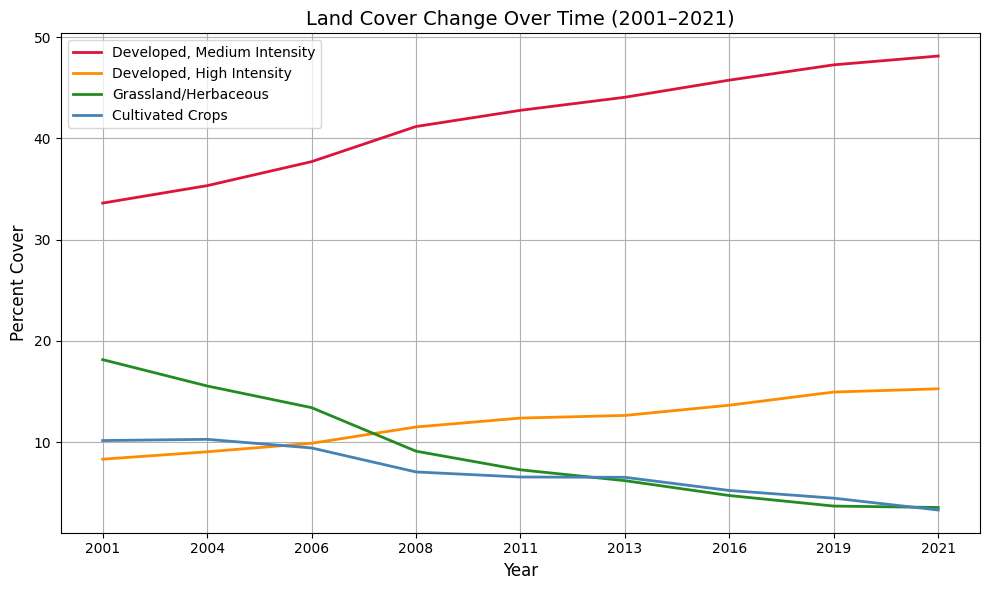

In [ ]:
import matplotlib.pyplot as plt

# Filter your DataFrame for selected categories
selected_classes = [
    'Developed, Medium Intensity',
    'Developed, High Intensity',
    'Grassland/Herbaceous',
    'Cultivated Crops'
]

# Ensure the years are sorted correctly
year_columns = ['2001', '2004', '2006','2008','2011','2013','2016','2019','2021']


df_plot = df_ordered.reset_index(drop=True)

# Filter and plot
plt.figure(figsize=(10, 6))

colors = {
    'Developed, Medium Intensity': 'crimson',
    'Developed, High Intensity': 'darkorange',
    'Grassland/Herbaceous': 'forestgreen',
    'Cultivated Crops': 'steelblue'
}

for label in selected_classes:
    row = df_plot[df_plot['Land Cover'] == label]
    if not row.empty:
        plt.plot(year_columns, row[year_columns].values.flatten(),
                 label=label, color=colors[label], linewidth=2)

plt.title('Land Cover Change Over Time (2001–2021)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percent Cover', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Calculate Nighttime Radiance YOY Change

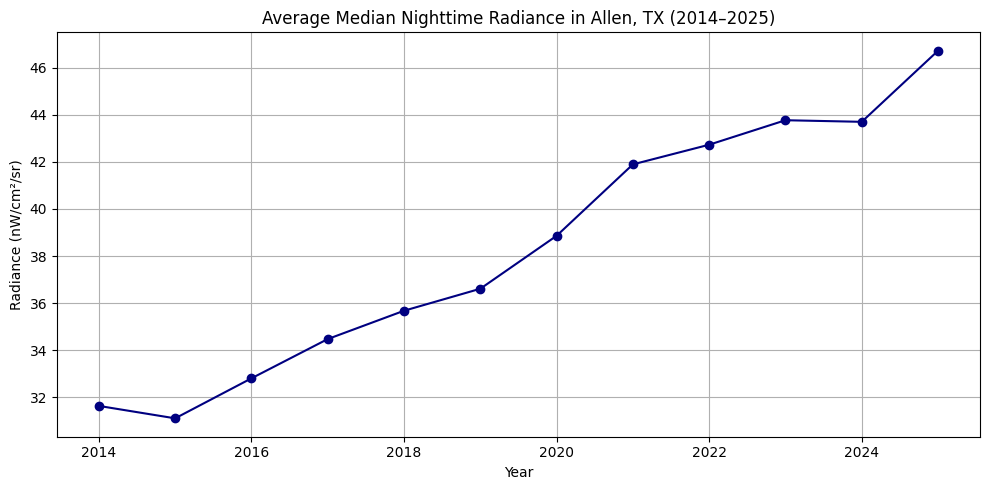

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import ee

# # Initialize Earth Engine
# ee.Initialize()

# Define the bounding box for Allen, TX
bbox = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])

# Define a list of years
years = list(range(2014, 2026))
results = []

for year in years:
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    image = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
             .filterDate(start_date, end_date)
             .select('avg_rad')
             .median()
             .clip(bbox))

    stat = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bbox,
        scale=500,
        maxPixels=1e9
    )

    results.append(stat.getInfo().get('avg_rad'))

# Create DataFrame
df = pd.DataFrame({'Year': years, 'Average_Median_Radiance': results})

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Average_Median_Radiance'], marker='o', color='navy')
plt.title('Average Median Nighttime Radiance in Allen, TX (2014–2025)')
plt.xlabel('Year')
plt.ylabel('Radiance (nW/cm²/sr)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import calendar

# Define years and initialize results
years = list(range(2014, 2026))
results = []
labels = []

for year in years:
    for month in range(1, 13):
        # Stop at March 2025 (last available in dataset)
        if year == 2025 and month > 3:
            break

        start_date = f"{year}-{month:02d}-01"
        end_day = calendar.monthrange(year, month)[1]
        end_date = f"{year}-{month:02d}-{end_day}"

        image = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
                 .filterDate(start_date, end_date)
                 .select('avg_rad')
                 .median()
                 .clip(bbox))

        stat = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=bbox,
            scale=500,
            maxPixels=1e9
        )

        avg_rad = stat.getInfo().get('avg_rad', None)
        results.append(avg_rad)
        labels.append(f"{year}-{month:02d}")

# Create DataFrame
df = pd.DataFrame({'Month': labels, 'Average_Median_Radiance': results})


In [ ]:
df

,Month,Average_Median_Radiance
0,2014-01,34.068612
1,2014-02,26.763332
2,2014-03,28.737563
3,2014-04,30.830918
4,2014-05,32.581364
...,...,...
130,2024-11,NaN
131,2024-12,45.391269
132,2025-01,49.573474
133,2025-02,49.140783


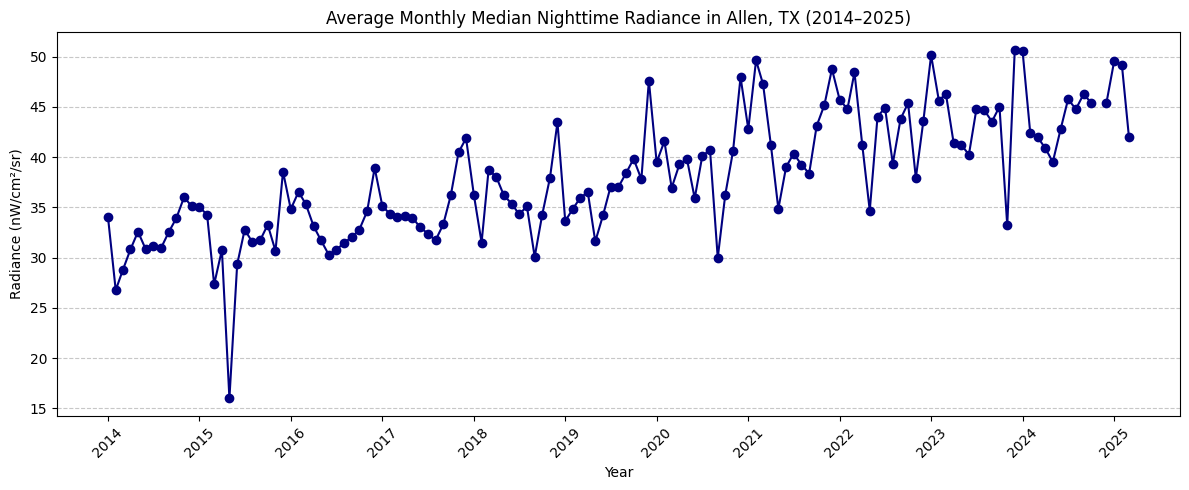

In [ ]:
# Ensure Month column is datetime
df['Month'] = pd.to_datetime(df['Month'])

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['Average_Median_Radiance'], marker='o', color='navy')

plt.title('Average Monthly Median Nighttime Radiance in Allen, TX (2014–2025)')
plt.xlabel('Year')
plt.ylabel('Radiance (nW/cm²/sr)')

# Set major ticks to yearly intervals
years = pd.date_range(start=df['Month'].min(), end=df['Month'].max(), freq='YS')
plt.xticks(ticks=years, labels=[d.year for d in years], rotation=45)

plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
